In [ ]:
from types import SimpleNamespace
import sys
import os
project_root = os.path.abspath("..")
sys.path.append(project_root)

import torch
import yaml
import re
import glob
from pathlib import Path

from src.models.lvsm_decoder_only import LVSMDecoderOnlyModel
from src.configs.lvsm_decoder_only_config import (
    LVSMDecoderOnlyModelConfig,
    RayEncodingType,
    PosEncType,
)
from src.prope.utils.transformer import (
    TransformerEncoderConfig,
    TransformerEncoderLayerConfig,
)


from src.data.dataset import TrainDataset
from src.data.latent_dataset import TrainLatentDataset
from main import LVSMLauncher, LVSMLauncherConfig


device = "cuda" if torch.cuda.is_available() else "cpu"


def get_config(overwrite):           
    
    dir = "../assets/vae_config.yaml" if overwrite.model_space == "VAE" else "../assets/px_config.yaml"
    raw = Path(dir).read_text()    
    clean = re.sub(r"!!python/[^ \n]+", "", raw)   # strip python tags

    config_dict = yaml.safe_load(clean)    
    cfg = LVSMLauncherConfig()

    for k, v in config_dict.items():
        if k != "model_config":   # we'll rebuild this separately
            setattr(cfg, k, v)
    
    m = config_dict["model_config"]

    # Enums were dumped as single-item lists
    ray_encoding = RayEncodingType(m["ray_encoding"][0])
    pos_enc      = PosEncType(m["pos_enc"][0])
    
    layer_cfg = m["encoder"]["layer"]

    encoder_layer = TransformerEncoderLayerConfig(
        d_model=layer_cfg["d_model"],
        nhead=layer_cfg["nhead"],
        dim_feedforward=overwrite.dim_feedforward,
        dropout=layer_cfg["dropout"],
        activation=torch.nn.functional.relu,  # original activation
        batch_first=layer_cfg["batch_first"],
        bias=layer_cfg["bias"],
        layer_norm_eps=layer_cfg["layer_norm_eps"],
        modulation_activation=layer_cfg["modulation_activation"],
        norm_first=layer_cfg["norm_first"],
        norm_type=layer_cfg["norm_type"],
        elementwise_affine=layer_cfg["elementwise_affine"],
        qk_norm=layer_cfg["qk_norm"],
    )
    
    encoder = TransformerEncoderConfig(
        layer=encoder_layer,
        num_layers=overwrite.num_layers,
        input_norm=m["encoder"]["input_norm"],
        output_norm=m["encoder"]["output_norm"],
        checkpointing=m["encoder"]["checkpointing"],
    )

    # Full model config
    model_cfg = LVSMDecoderOnlyModelConfig(
        ref_views=m["ref_views"],
        tar_views=m["tar_views"],
        encoder=encoder,
        img_shape=tuple([m["img_shape"][0]*overwrite.scale_factor, m["img_shape"][1]*overwrite.scale_factor,m["img_shape"][2]]),
        cam_shape=tuple([m["cam_shape"][0]*overwrite.scale_factor, m["cam_shape"][1]*overwrite.scale_factor,m["cam_shape"][2]]),        
        patch_size=overwrite.patch_size,        
        ray_encoding=ray_encoding,
        pos_enc=pos_enc,
    )
    
    cfg.model_config = model_cfg    
    return cfg

# ckpt_path = "/home/felix/LVSM_VAE2/LVSM-VAE/results/ckpt_1/step-000644700.pt"
ckpt_path = "/home/teampc/LVSM-VAE/results/nvs/VAE/release-1gpus-b8-s1-80k-CAMRAY-PROPE/ckpts/best_for_now/step-000870100.pt"

ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=True)
state_dict = {k.replace("_orig_mod.", ""): v for k, v in ckpt["model"].items()}

ow = SimpleNamespace()
ow.model_space = 'VAE'
ow.scale_factor = 1
ow.patch_size = 2
ow.supervise_views = 0
ow.dim_feedforward = 1024
ow.num_layers = 6

cfg = get_config(ow)
model = LVSMDecoderOnlyModel(cfg.model_config).to(device)
model.eval()

missing, unexpected = model.load_state_dict(state_dict, strict=False)

print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

/home/felix/miniconda3/envs/lvsmvae/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Missing keys: []
Unexpected keys: []


In [ ]:
# manual import

from einops import rearrange

# import matplotlib.pyplot as plt

scenes = torch.load("/home/teampc/LVSM-VAE/data/single_torch/000270.torch")
# scenes = torch.load("/home/felix/LVSM_VAE2/LVSM-VAE/data/test/000271.torch")
scene = scenes[0]
# image = scene["images"][1]
# image = rearrange(image,"n h c w -> n c w h")
# print(f"image min: {image.min()} - max: {image.max()}")
# raw_px = l.decode_tensors(image).squeeze() 
# plt.imshow(raw_px.cpu())
# plt.axis("off")
# plt.show()

scene["key"]

'3dfaa97cd48a0332'

In [ ]:
from src.data.torch_latent_dataset import LVSMLatentDataset, EvalLVSMLatentDataset
from main import LVSMLauncher

INPUT_VIEWS = 8
# INPUT_VIEWS = 4 # the remaining 5 - INPUT_VIEWS will be targets

# eval_path = f"/home/felix/LVSM_VAE2/LVSM-VAE/assets/eval_{INPUT_VIEWS}_in.json"
eval_path = f"/home/teampc/LVSM-VAE/assets/eval_{INPUT_VIEWS}_in.json"

SUPERVISE_VIEWS = 1 # no effect
# ds = LVSMLatentDataset(roots="/home/felix/LVSM_VAE2/LVSM-VAE/data/test", input_views=INPUT_VIEWS, supervise_views=SUPERVISE_VIEWS)
# ds = EvalLVSMLatentDataset(torch_root="/home/felix/LVSM_VAE2/LVSM-VAE/data/test",index_json_path=eval_path, input_views=INPUT_VIEWS, supervise_views=SUPERVISE_VIEWS)
ds = EvalLVSMLatentDataset(torch_root="/home/teampc/LVSM-VAE/data/single_torch",index_json_path=eval_path, input_views=INPUT_VIEWS, supervise_views=SUPERVISE_VIEWS)
dataloader = torch.utils.data.DataLoader(ds,shuffle=False, num_workers=0)
dataiter = iter(dataloader)
data = next(dataiter)

l = LVSMLauncher(LVSMLauncherConfig(model_space = "VAE"))

processed = l.preprocess(data, input_views=INPUT_VIEWS)

ref_imgs, tar_imgs = processed["ref_imgs"], processed["tar_imgs"]
ref_cams, tar_cams = processed["ref_cams"], processed["tar_cams"]

print(f"ref: {ref_imgs.shape} - tar: {tar_imgs.shape}")

with torch.no_grad():
    out = model(ref_imgs.to(device), ref_cams, tar_cams)

out_px = l.decode_tensors(out).squeeze(0).detach() 
tar_px = l.decode_tensors(tar_imgs).squeeze(0).detach()  
ref_px = l.decode_tensors(ref_imgs).squeeze(0).detach()  

Wrote config to results/dbg/config.yaml
ref: torch.Size([1, 8, 32, 32, 16]) - tar: torch.Size([1, 1, 32, 32, 16])


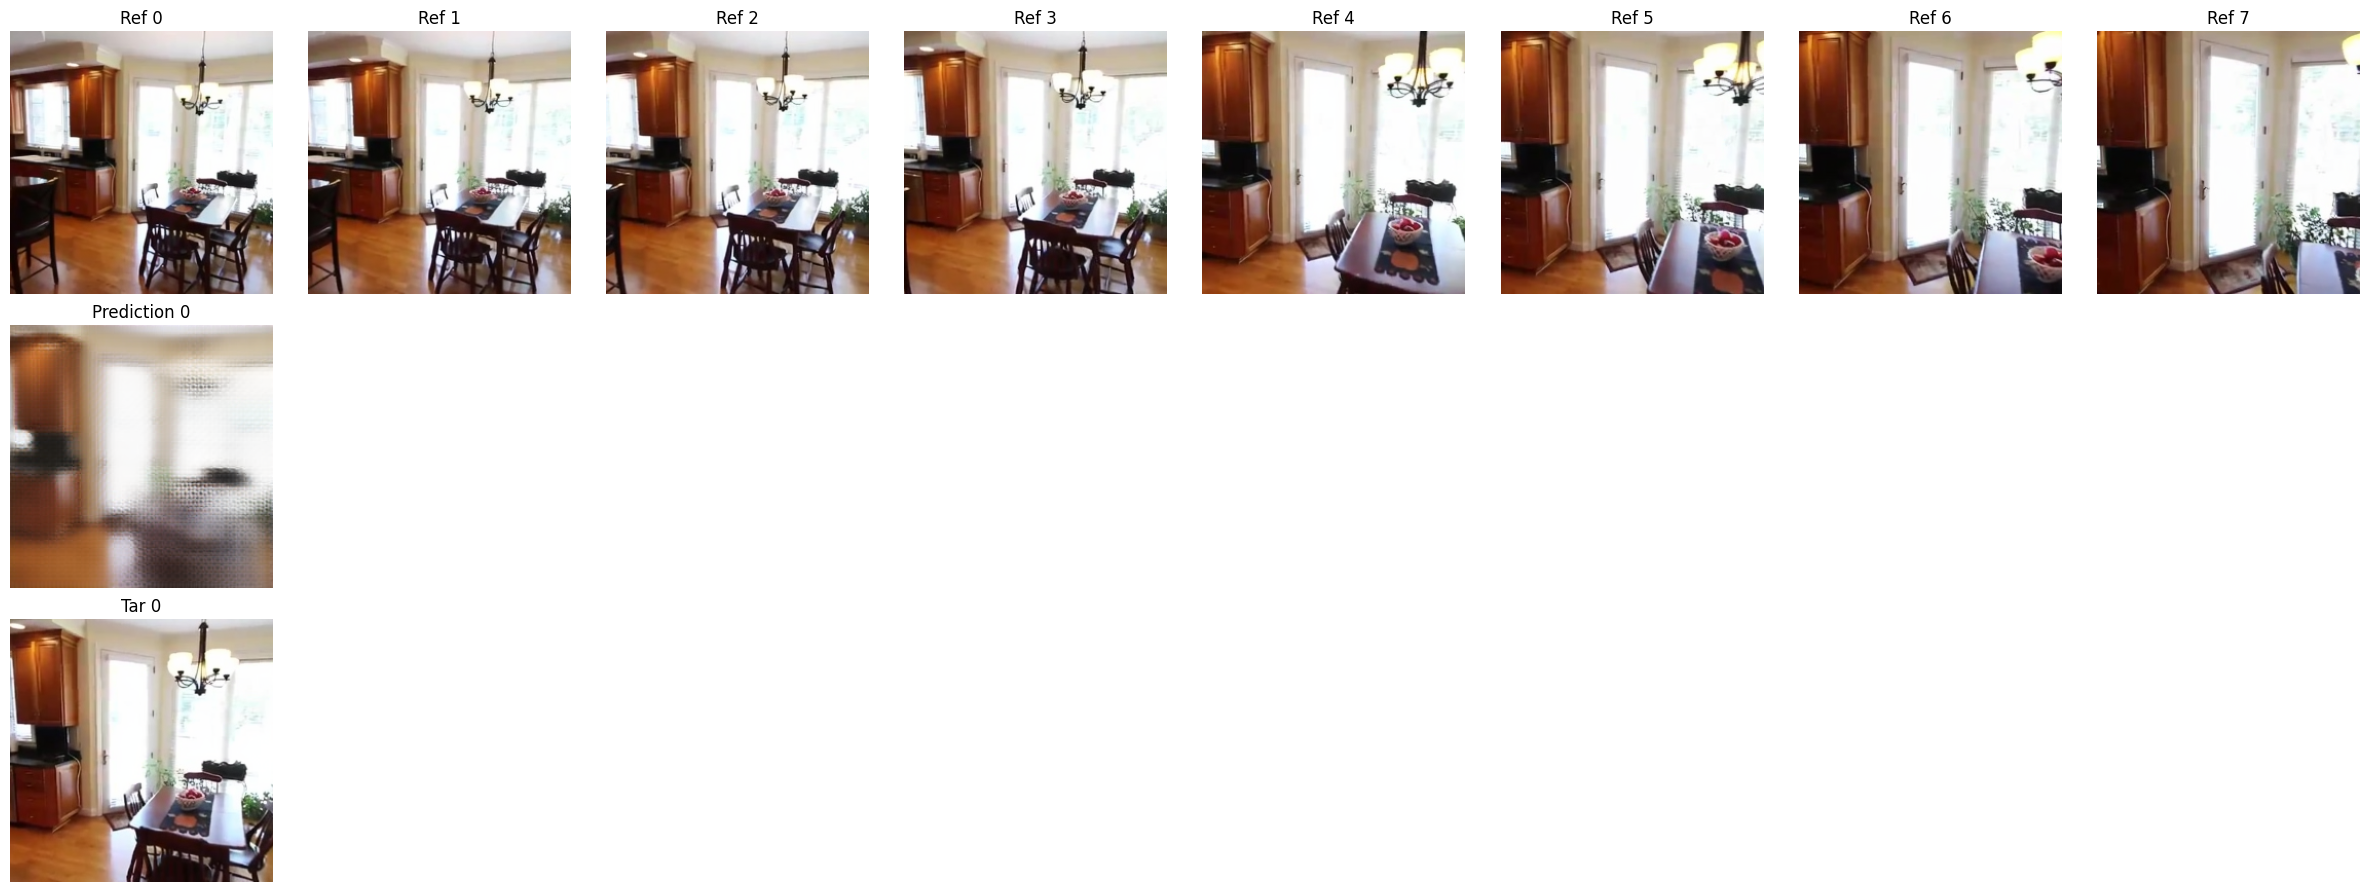

psn: 16.70128059387207
ssim: 0.5539305210113525
lpips: 0.5544030070304871


In [4]:
import matplotlib.pyplot as plt

n_ref = ref_px.shape[0]
n_tar = tar_px.shape[0]
n_cols = max(n_ref, n_tar)

fig, axes = plt.subplots(3, n_cols, figsize=(3 * n_cols, 9))

# --- References ---
for i in range(n_cols):
    ax = axes[0, i]
    ax.axis("off")
    if i < n_ref:
        ax.imshow(ref_px[i].cpu())
        ax.set_title(f"Ref {i}")

# --- Outputs ---
for i in range(n_cols):
    ax = axes[1, i]
    ax.axis("off")
    if i < n_tar:
        ax.imshow(out_px[i].cpu())
        ax.set_title(f"Prediction {i}")

# --- Targets ---
for i in range(n_cols):
    ax = axes[2, i]
    ax.axis("off")
    if i < n_tar:
        ax.imshow(tar_px[i].cpu())
        ax.set_title(f"Tar {i}")

plt.tight_layout()
plt.show()


from einops import rearrange
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
from torchmetrics.image.lpip import LearnedPerceptualImagePatchSimilarity

psnr_fn = PeakSignalNoiseRatio(data_range=1.0)
ssim_fn = StructuralSimilarityIndexMeasure(data_range=1.0)
lpips_fn = LearnedPerceptualImagePatchSimilarity(
    net_type="alex", normalize=True
)

pred = rearrange(out_px.detach(),"B W H C -> B C W H").cpu()
gt = rearrange(tar_px.detach(),"B W H C -> B C W H").cpu()

psnr = psnr_fn(pred,gt)
ssim = ssim_fn(pred,gt)
lpips = lpips_fn(pred,gt)

print(f"psn: {psnr}\nssim: {ssim}\nlpips: {lpips}")



In [5]:
l = LVSMLauncher(LVSMLauncherConfig(model_space = "VAE"))
data_path = "/mnt/e/lvsm/re10k_latent_full_test"
SUPERVISE_VIEWS = 1 # no effect

# max_n = 10

# INPUT_VIEWS = 2
# INPUT_VIEWS = 4 # the remaining 5 - INPUT_VIEWS will be targets
# choose 2 / 4 / 6 / 8
for v in range(4):
    INPUT_VIEWS = (v+1)*2
            
    if INPUT_VIEWS == 4:
        eval_path = f"/home/felix/LVSM_VAE2/LVSM-VAE/assets/evaluation_index_re10k.json"
    else:
        eval_path = f"/home/felix/LVSM_VAE2/LVSM-VAE/assets/evaluation_index_re10k_{INPUT_VIEWS}in.json"
    
    ds = EvalLVSMLatentDataset(torch_root=data_path, index_json_path=eval_path, input_views=INPUT_VIEWS, supervise_views=SUPERVISE_VIEWS)    
    dataloader = torch.utils.data.DataLoader(ds,shuffle=False, num_workers=0)
    dataiter = iter(dataloader)
    
    psnr = 0
    ssim = 0
    lpips = 0

    n = 0    

    import tqdm
    for data in tqdm.tqdm(dataloader, desc="Testing"):        
        
        n += 1
        # if n >= max_n: break

        data = next(dataiter)        
        processed = l.preprocess(data, input_views=INPUT_VIEWS)

        ref_imgs, tar_imgs = processed["ref_imgs"], processed["tar_imgs"]
        ref_cams, tar_cams = processed["ref_cams"], processed["tar_cams"]    

        with torch.no_grad():
            out = model(ref_imgs.to(device), ref_cams, tar_cams)

        out_px = l.decode_tensors(out).squeeze(0).detach() 
        tar_px = l.decode_tensors(tar_imgs).squeeze(0).detach()  
        # ref_px = l.decode_tensors(ref_imgs).squeeze(0).detach()  

        pred = rearrange(out_px.detach(),"B W H C -> B C W H").cpu()
        gt = rearrange(tar_px.detach(),"B W H C -> B C W H").cpu()

        psnr += psnr_fn(pred,gt)
        ssim += ssim_fn(pred,gt)
        lpips += lpips_fn(pred,gt)


    mean_psnr = psnr / n
    mean_ssim = ssim / n
    mean_lpips = lpips / n

    print(f"metrics for {INPUT_VIEWS} input → 1 output:")
    print(f"\npsn: {mean_psnr}\nssim: {mean_ssim}\nlpips: {mean_lpips}")

Wrote config to results/dbg/config.yaml


OSError: [Errno 12] Cannot allocate memory